#Generate Realistic Dataset(50 Samples)
Cluster 1:Low Yield,low water usage(overlapping)
#Cluster 2:High Yield,high water usage(but overlapping)
#Combine and Shuffle
Sample Data:
    soil_nitrogen    rainfall      yield  water_usage
0      65.181508  530.055841  10.914471   253.067627
1      84.722306  804.571420  17.349682   436.541662
2      87.412379  718.196795  15.444450   341.237799
3      77.724900  601.043943  12.390223   265.167674
4      91.015464  720.790624  14.949099   367.322549
#2.preprocessing(Scaling)
#Apply K-Means
#cluster centres

 Cluster Centres:
    soil_nitrogen    rainfall      yield  water_usage
0      58.111029  469.872427  10.051300   231.402183
1      84.940930  687.797200  14.658722   345.341034
#5 evaluation matrics
Inertia (WCSS): 67.08368239326083
Silhouette Score: 0.541873436339785
Davies-Bouldin Index: 0.645021861227679
#6.Elbow Method


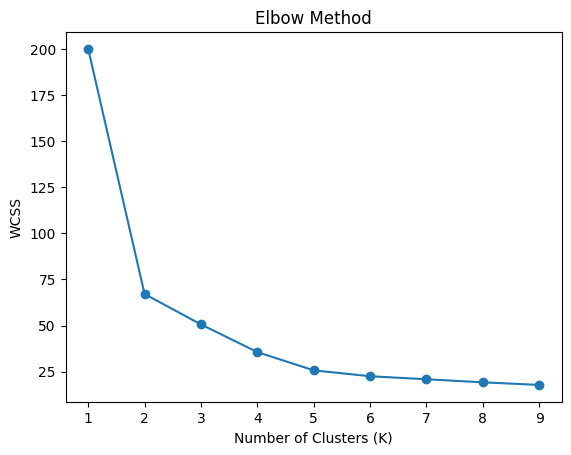

#7.Visualization (Overlapping clusters)


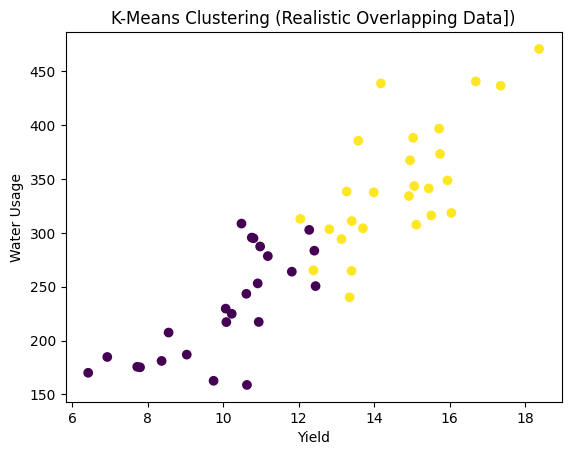

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,davies_bouldin_score
from sklearn.preprocessing import StandardScaler

print("#Generate Realistic Dataset(50 Samples)")
np.random.seed(42)
n_samples=50

print("Cluster 1:Low Yield,low water usage(overlapping)")

cluster1=pd.DataFrame({
    'soil_nitrogen':np.random.normal(60,8,n_samples//2),
    'rainfall':np.random.normal(500,80,n_samples//2),
    })

cluster1['yield']=0.02*cluster1['rainfall']+0.01*cluster1['soil_nitrogen']+np.random.normal(0,0.5,n_samples//2)
cluster1['water_usage']=0.5*cluster1['rainfall']+np.random.normal(0,40,n_samples//2)

print("#Cluster 2:High Yield,high water usage(but overlapping)")
cluster2=pd.DataFrame({
    'soil_nitrogen':np.random.normal(85,8,n_samples//2),
    'rainfall':np.random.normal(700,80,n_samples//2),
    })
cluster2['yield']=0.02*cluster2['rainfall']+0.01*cluster2['soil_nitrogen']+np.random.normal(0,0.5,n_samples//2)
cluster2['water_usage']=0.5*cluster2['rainfall']+np.random.normal(0,40,n_samples//2)

print("#Combine and Shuffle")
data=pd.concat([cluster1,cluster2]).sample(frac=1).reset_index(drop=True)

print("Sample Data:\n",data.head())

print("#2.preprocessing(Scaling)")
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data)

print("#Apply K-Means")
k=2
kmeans=KMeans(n_clusters=k,random_state=42)
kmeans.fit(scaled_data)

labels=kmeans.labels_
data['cluster']=labels

print("#cluster centres")
centroids=scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df=pd.DataFrame(centroids,columns=data.columns[:-1])

print("\n Cluster Centres:\n",centroids_df)

print("#5 evaluation matrics")
#(a)Inertia (WCSS)
print("Inertia (WCSS):",kmeans.inertia_)

#(b)Silhouette Score
sil_score=silhouette_score(scaled_data,labels)
print("Silhouette Score:",sil_score)

#(c)Davies-Bouldin Index
db_index=davies_bouldin_score(scaled_data,labels)
print("Davies-Bouldin Index:",db_index)

print("#6.Elbow Method")

wcss=[]
K_range=range(1,10)
for k_val in K_range:
    kmeans=KMeans(n_clusters=k_val,random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range,wcss,marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

print("#7.Visualization (Overlapping clusters)")
plt.figure()
plt.scatter(data['yield'],data['water_usage'],c=labels)
plt.xlabel('Yield')
plt.ylabel('Water Usage')
plt.title('K-Means Clustering (Realistic Overlapping Data])')
plt.show()